In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

- Loading the dataset

In [102]:
df = pd.read_csv("covid_19_data.csv")

- checking first rows

In [103]:
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


- Checking for the dataset structure 

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo              306429 non-null  int64  
 1   ObservationDate  306429 non-null  object 
 2   Province/State   228326 non-null  object 
 3   Country/Region   306429 non-null  object 
 4   Last Update      306429 non-null  object 
 5   Confirmed        306429 non-null  float64
 6   Deaths           306429 non-null  float64
 7   Recovered        306429 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 18.7+ MB


- selecting the necessary columns

In [105]:
df = df[['ObservationDate', 'Confirmed']]

- Ensuring proper ordering

In [106]:
df = df[['ObservationDate', 'Confirmed']]

df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])
df = df.sort_values('ObservationDate')

- Aggregating by Date

In [107]:
df = df.groupby('ObservationDate')['Confirmed'].sum().reset_index()

- Computing new cases

In [108]:
df['New_Cases'] = df['Confirmed'].diff()

- Checking for missing values

In [109]:
df.isnull().sum()

ObservationDate    0
Confirmed          0
New_Cases          1
dtype: int64

- Handle Missing

In [110]:
df['New_Cases'] = df['New_Cases'].fillna(0)

# Remove negative values (important for realism)
df['New_Cases'] = df['New_Cases'].clip(lower=0)

- Setting an Index for Time Series

In [111]:
df.set_index('ObservationDate', inplace=True)

In [112]:
print(df.head())

                 Confirmed  New_Cases
ObservationDate                      
2020-01-22           557.0        0.0
2020-01-23          1097.0      540.0
2020-01-24           941.0        0.0
2020-01-25          1437.0      496.0
2020-01-26          2118.0      681.0


- Visualization

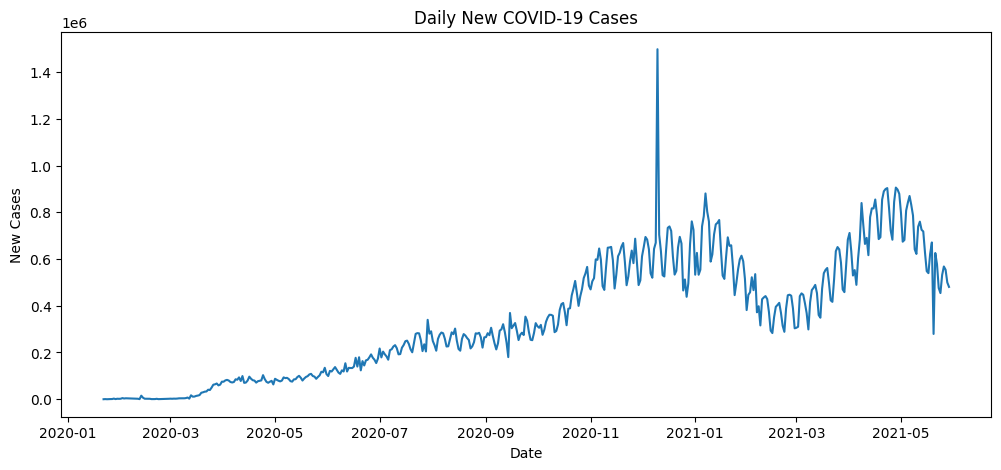

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['New_Cases'])
plt.title('Daily New COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.show()

- Summary Statistics

In [114]:
df.describe()

,Confirmed,New_Cases
count,4.940000e+02,4.940000e+02
mean,5.314181e+07,3.440307e+05
std,5.289685e+07,2.551706e+05
min,5.570000e+02,0.000000e+00
25%,5.432008e+06,1.006088e+05
50%,3.245885e+07,2.936535e+05
75%,1.001883e+08,5.395918e+05
max,1.699516e+08,1.498213e+06


- Rolling Mean & Standard Deviation

In [115]:
window = 7

df['Rolling_Mean'] = df['New_Cases'].rolling(window=window).mean()
df['Rolling_Std'] = df['New_Cases'].rolling(window=window).std()

- Plotting the Rolling Statistics

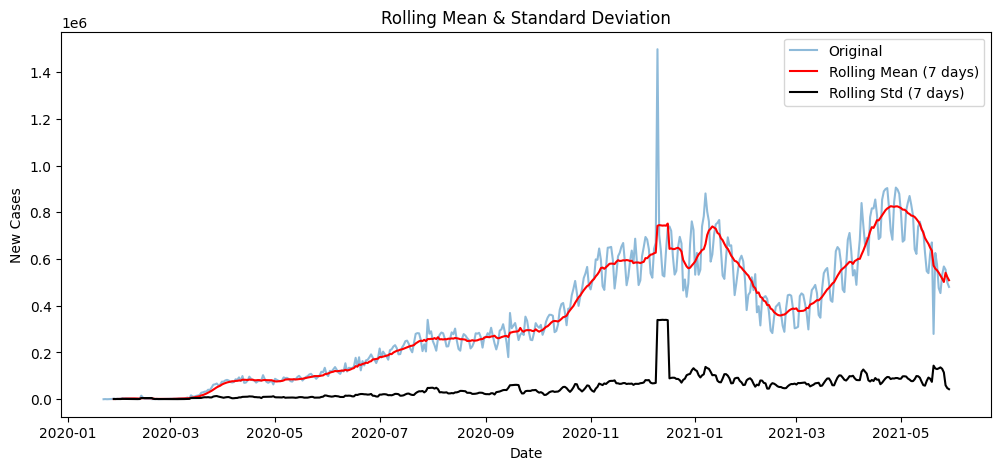

In [116]:

plt.figure(figsize=(12,5))

plt.plot(df['New_Cases'], label='Original', alpha=0.5)
plt.plot(df['Rolling_Mean'], label='Rolling Mean (7 days)', color='red')
plt.plot(df['Rolling_Std'], label='Rolling Std (7 days)', color='black')

plt.legend()
plt.title('Rolling Mean & Standard Deviation')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.show()

- The plot shows non-stationary data with a strong upward trend and clear seasonality, which is likely driven by weekly reporting cycles

## Time Series Decomposition

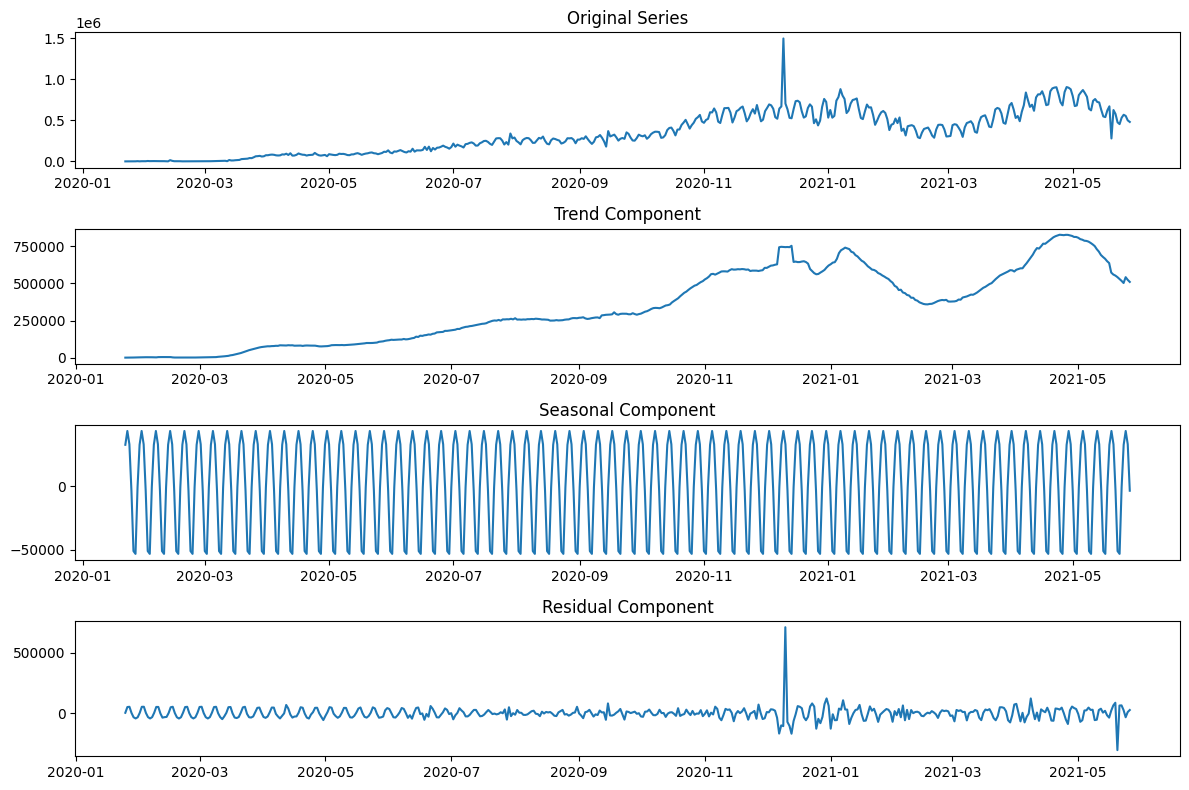

In [117]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['New_Cases'], model='additive', period=7)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(df['New_Cases'])
plt.title('Original Series')

plt.subplot(4,1,2)
plt.plot(trend)
plt.title('Trend Component')

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title('Seasonal Component')

plt.subplot(4,1,4)
plt.plot(residual)
plt.title('Residual Component')

plt.tight_layout()
plt.show()

- An additive decomposition model is selected because the seasonal fluctuations remain approximately constant in magnitude over time, rather than increasing proportionally with the level of the series. This indicates that the components combine linearly rather than multiplicatively

## Checking for the  Variance

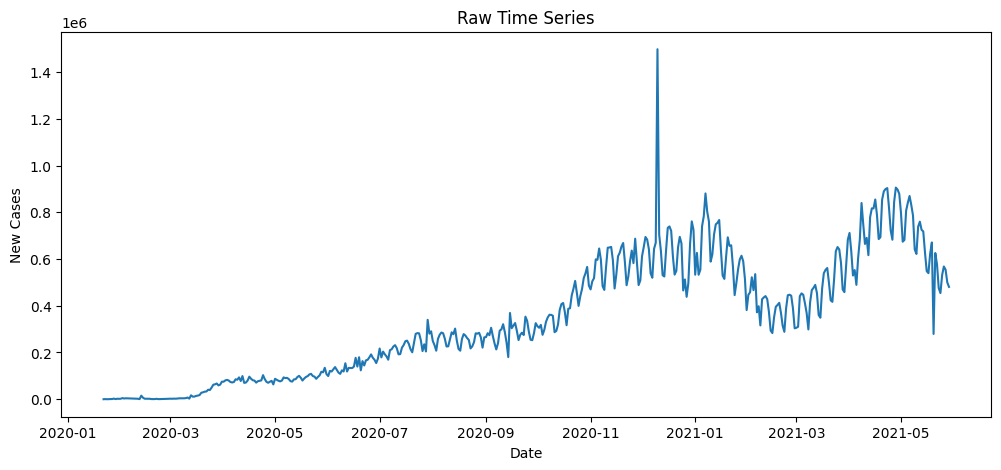

In [118]:
plt.figure(figsize=(12,5))
plt.plot(df['New_Cases'])
plt.title('Raw Time Series')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.show()

- This plot shows that the variance increases over time thus a need to use log transformation

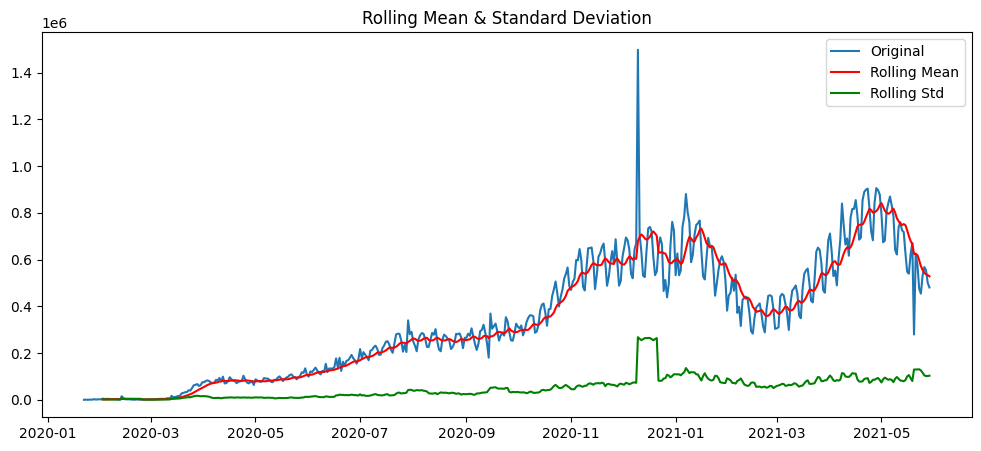

In [119]:
rolling_mean = df['New_Cases'].rolling(window=12).mean()
rolling_std = df['New_Cases'].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df['New_Cases'], label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='green', label='Rolling Std')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

This shows that the rolling mean is non constant thus a call to use log transformation to stabilize the time series

## Applying Log Transformation

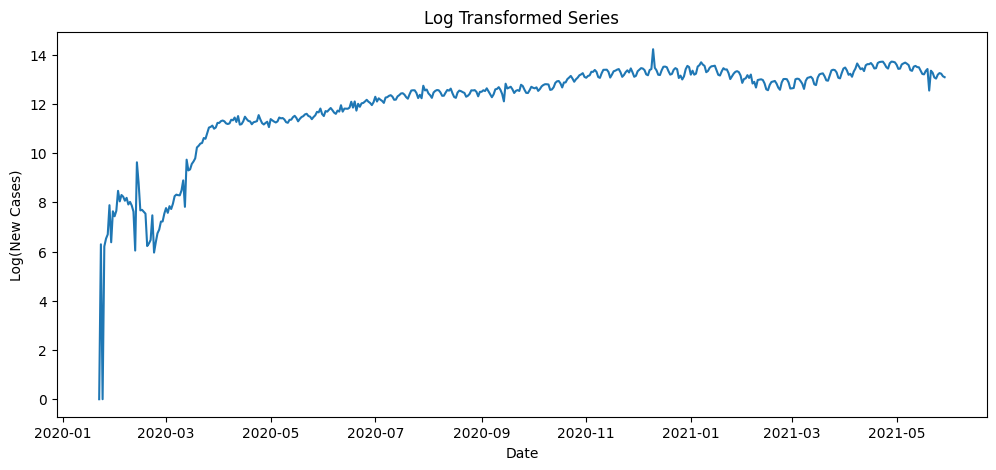

In [120]:
import numpy as np

df['Log_Cases'] = np.log(df['New_Cases'] + 1)  # +1 avoids log(0)
plt.figure(figsize=(12,5))
plt.plot(df['Log_Cases'])
plt.title('Log Transformed Series')
plt.xlabel('Date')
plt.ylabel('Log(New Cases)')
plt.show()

- The transformation helps in compressing the large values thus reducing the increasing variance that was observed in the original series. This gives a more stable time series ready for modeling

## Comparing Before and After Transformation

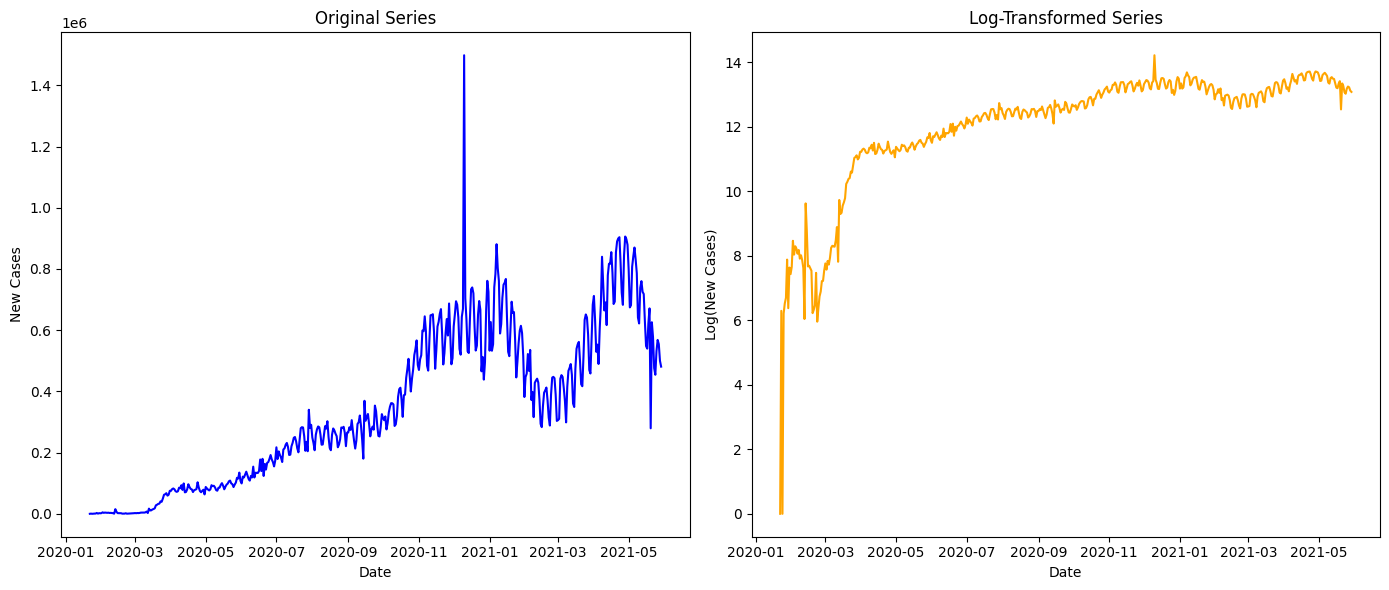

In [121]:

plt.figure(figsize=(14,6))

# Original series
plt.subplot(1, 2, 1)
plt.plot(df['New_Cases'], color='blue')
plt.title('Original Series')
plt.xlabel('Date')
plt.ylabel('New Cases')

# Log-transformed series
plt.subplot(1, 2, 2)
plt.plot(df['Log_Cases'], color='orange')
plt.title('Log-Transformed Series')
plt.xlabel('Date')
plt.ylabel('Log(New Cases)')

plt.tight_layout()
plt.show()

## Milestone 2

## Stationarity Test (ADF Test)

In [122]:
df_clean = df['Log_Cases'].dropna()

In [123]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Log_Cases'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

# Decision rule
if result[1] < 0.05:
    print("\nConclusion: Reject the null hypothesis.")
    print("The time series is stationary.")
else:
    print("\nConclusion: Fail to reject the null hypothesis.")
    print("The time series is non-stationary.")

ADF Statistic: -3.7445348535760807
p-value: 0.003528597054465799
Critical Values:
1%: -3.4441920863262863
5%: -2.8676439813617147
10%: -2.570021186703601

Conclusion: Reject the null hypothesis.
The time series is stationary.


## Plotting ACF and PACF

<Figure size 1200x500 with 0 Axes>

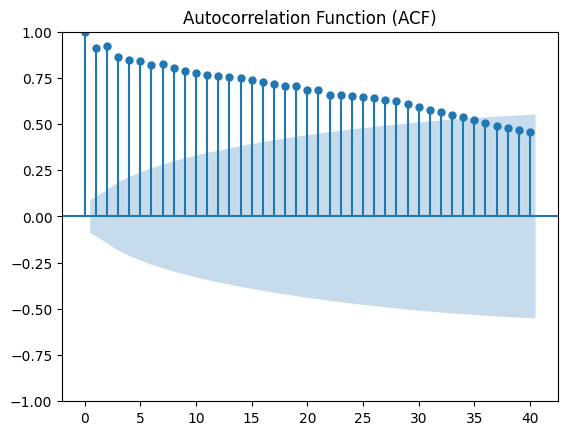

<Figure size 1200x500 with 0 Axes>

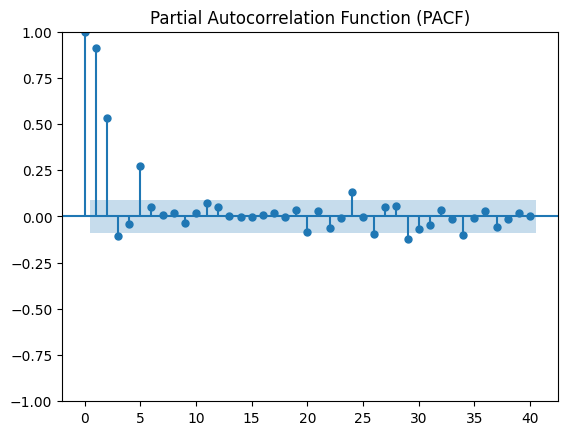

In [124]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF
plt.figure(figsize=(12,5))
plot_acf(df['Log_Cases'], lags=40)
plt.title('Autocorrelation Function (ACF)')
plt.show()

# Plot PACF
plt.figure(figsize=(12,5))
plot_pacf(df['Log_Cases'], lags=40)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

- The plots indicate that the series is non-stationary, characterized by an ACF that decays very slowly and a PACF that shows a sharp cutoff after the first few lags.

## Applying First-Order Differencing

In [125]:
df['diff_log_cases'] = df['Log_Cases'].diff()
df = df.dropna()

## Plotting the Differenced Series

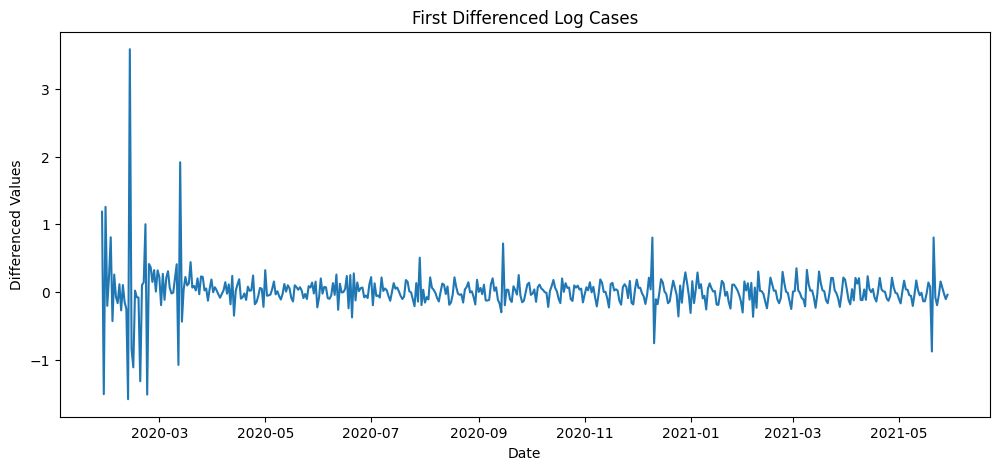

In [126]:
plt.figure(figsize=(12,5))
plt.plot(df['diff_log_cases'])
plt.title("First Differenced Log Cases")
plt.xlabel("Date")
plt.ylabel("Differenced Values")
plt.show()

<Figure size 1200x500 with 0 Axes>

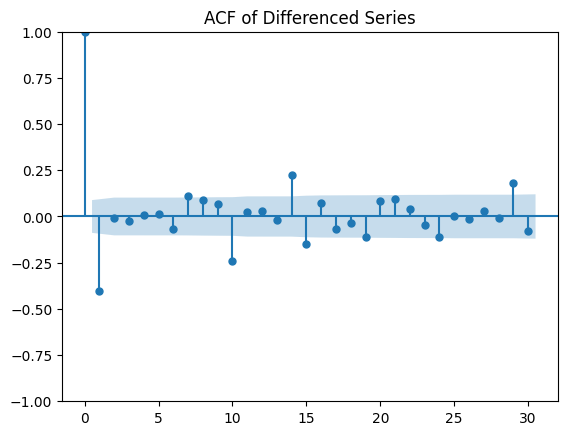

<Figure size 1200x500 with 0 Axes>

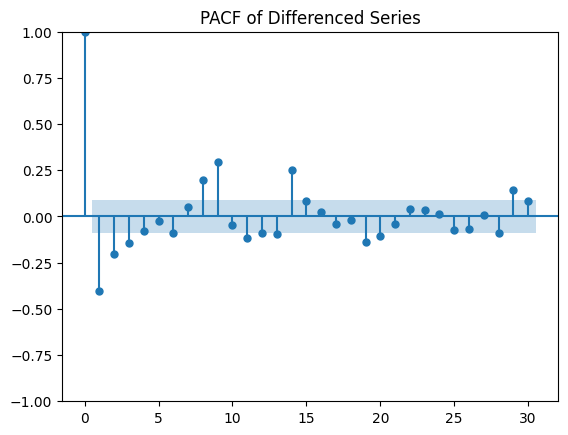

In [127]:
plt.figure(figsize=(12,5))
plot_acf(df['diff_log_cases'], lags=30)
plt.title("ACF of Differenced Series")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['diff_log_cases'], lags=30)
plt.title("PACF of Differenced Series")
plt.show()

In [128]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['diff_log_cases'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is non-stationary.")

ADF Statistic: -4.816233994110856
p-value: 5.0627542548398415e-05
Series is stationary.


## Applying Second Differencing

In [129]:
df['diff2_log_cases'] = df['diff_log_cases'].diff()
df = df.dropna()

## Plotting the Second Differenced Series

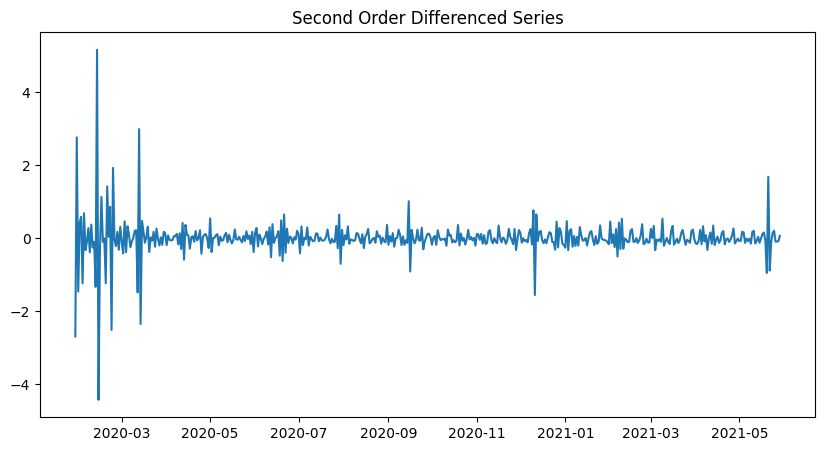

In [130]:
plt.figure(figsize=(10,5))
plt.plot(df['diff2_log_cases'])
plt.title("Second Order Differenced Series")
plt.show()

In [131]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['diff2_log_cases'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is non-stationary.")

ADF Statistic: -8.666810907756629
p-value: 4.660468594274236e-14
Series is stationary.


# Milestone 3

## Model Development & Smoothing

## Fitting the ARIMA Model

In [132]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Log_Cases'], order=(2, 1, 1))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:              Log_Cases   No. Observations:                  487
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 -47.659
Date:                Sat, 21 Mar 2026   AIC                            103.318
Time:                        20:59:09   BIC                            120.063
Sample:                    01-29-2020   HQIC                           109.896
                         - 05-29-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0250      0.082      0.305      0.760      -0.135       0.185
ar.L2         -0.0517      0.045     -1.155      0.248      -0.139       0.036
ma.L1         -0.5001      0.076     -6.563      0.0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Fitting a Second ARIMA Model

In [133]:
from statsmodels.tsa.arima.model import ARIMA

model2 = ARIMA(df['Log_Cases'], order=(2, 1, 0))
results2 = model2.fit()

print(results2.summary())

                               SARIMAX Results                                
Dep. Variable:              Log_Cases   No. Observations:                  487
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 -52.670
Date:                Sat, 21 Mar 2026   AIC                            111.341
Time:                        20:59:09   BIC                            123.899
Sample:                    01-29-2020   HQIC                           116.274
                         - 05-29-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4362      0.022    -19.746      0.000      -0.479      -0.393
ar.L2         -0.2076      0.024     -8.738      0.000      -0.254      -0.161
sigma2         0.0727      0.002     39.292      0.0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Compare the Two Models Using AIC and BIC

In [134]:
print("Model Comparison")

print("ARIMA(2,1,1) AIC:", results.aic)
print("ARIMA(2,1,0) AIC:", results2.aic)

print("ARIMA(2,1,1) BIC:", results.bic)
print("ARIMA(2,1,0) BIC:", results2.bic)

Model Comparison
ARIMA(2,1,1) AIC: 103.3178438273968
ARIMA(2,1,0) AIC: 111.34055798455945
ARIMA(2,1,1) BIC: 120.06267832299878
ARIMA(2,1,0) BIC: 123.89918385626093


- The ARIMA(2, 1, 1) provides a better balance between complexity and accuracy. The inclusion of that single MA term likely helps the model account for the "shocks" or sudden changes in daily cases that the pure Autoregressive (2, 1, 0) model was missing.

# Milestone 4

## Model Evaluation & Reporting

## Forecasting

In [135]:
forecast = results2.forecast(steps=10)

print("10-step Forecast:")
print(forecast)

10-step Forecast:
2021-05-30    13.121727
2021-05-31    13.113044
2021-06-01    13.108850
2021-06-02    13.112482
2021-06-03    13.111768
2021-06-04    13.111326
2021-06-05    13.111667
2021-06-06    13.111610
2021-06-07    13.111564
2021-06-08    13.111596
Freq: D, Name: predicted_mean, dtype: float64


## Converting the Forecast Back to Actual Cases

In [136]:
actual_forecast = np.exp(forecast)

print("Forecasted Cases:")
print(actual_forecast)

Forecasted Cases:
2021-05-30    499681.799696
2021-05-31    495361.769620
2021-06-01    493288.849269
2021-06-02    495083.563003
2021-06-03    494730.421455
2021-06-04    494511.472257
2021-06-05    494680.232623
2021-06-06    494652.067620
2021-06-07    494629.315773
2021-06-08    494645.086167
Freq: D, Name: predicted_mean, dtype: float64


- Using the selected ARIMA(2,1,1) model, a 10-day ahead forecast was generated, predicting the number of COVID-19 cases to range between approximately 493,289 and 499,682. 
- The forecast shows minor initial fluctuations before stabilizing around a mean of 494,600 cases. This trend suggests that the growth of new cases may begin to level off during the forecast horizon, following the recent deceleration seen in the historical data.

## Forecast Confidence Intervals

In [137]:
forecast_result = results2.get_forecast(steps=10)

forecast_values = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()

print(confidence_intervals)

            lower Log_Cases  upper Log_Cases
2021-05-30        12.593318        13.650136
2021-05-31        12.506434        13.719654
2021-06-01        12.437016        13.780685
2021-06-02        12.359239        13.865725
2021-06-03        12.293411        13.930125
2021-06-04        12.233294        13.989357
2021-06-05        12.176032        14.047301
2021-06-06        12.122320        14.100900
2021-06-07        12.071458        14.151670
2021-06-08        12.022899        14.200292


In [138]:
print(confidence_intervals.columns)

Index(['lower Log_Cases', 'upper Log_Cases'], dtype='object')


In [139]:
lower_cases = np.exp(confidence_intervals['lower Log_Cases'])
upper_cases = np.exp(confidence_intervals['upper Log_Cases'])

print(lower_cases)
print(upper_cases)

2021-05-30    294583.447655
2021-05-31    270069.210904
2021-06-01    251957.529516
2021-06-02    233103.763236
2021-06-03    218253.192075
2021-06-04    205519.046334
2021-06-05    194081.308030
2021-06-06    183931.763865
2021-06-07    174810.553896
2021-06-08    166524.728718
Freq: D, Name: lower Log_Cases, dtype: float64
2021-05-30    8.475761e+05
2021-05-31    9.085941e+05
2021-06-01    9.657734e+05
2021-06-02    1.051496e+06
2021-06-03    1.121442e+06
2021-06-04    1.189873e+06
2021-06-05    1.260856e+06
2021-06-06    1.330280e+06
2021-06-07    1.399562e+06
2021-06-08    1.469294e+06
Freq: D, Name: upper Log_Cases, dtype: float64


- Converting the confidence intervals from the log scale to the actual case counts shows that the forecasted number of Covid-19 cases lies within a defined range of lower and upper bounds such as on May 30th, 2021, the model predicts that the cases could range between approximately 294,583 (lower bound) and 847,576 (upper bound).

- Over time, the width of the confidence interval increases, which reflects growing uncertainty in the forecasts as the horizon extends. This is typical of ARIMA model behavior, where prediction errors accumulate for longer-term forecasts.

## Evaluation metrics (MAE, RMSE, MAPE)

## Splitting Data into Train and Test

In [140]:
train = df['Log_Cases'][:-10]
test = df['Log_Cases'][-10:]

## Fitting the ARIMA Model on Training Data

In [141]:
model = ARIMA(train, order=(2,1,1))
model_fit = model.fit()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Forecasting the Test Period

In [142]:
forecast = model_fit.forecast(steps=10)

## Calculating the Accuracy Metrics

In [143]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.2439006347893166
RMSE: 0.32448770166878044
MAPE: 1.8879130772473254


- Using the forecasting performance of the ARIMA(2,1,1) model, the prediction errors were evaluated using MAE, RMSE, and MAPE. The model produced a MAE of 0.244, RMSE of 0.324, indicating relatively small prediction errors in the log-transformed series.
- The MAPE of 1.89% suggests that the model provides highly accurate forecasts with minimal deviation from the actual observed values.

## Plotting Actual vs Forecast

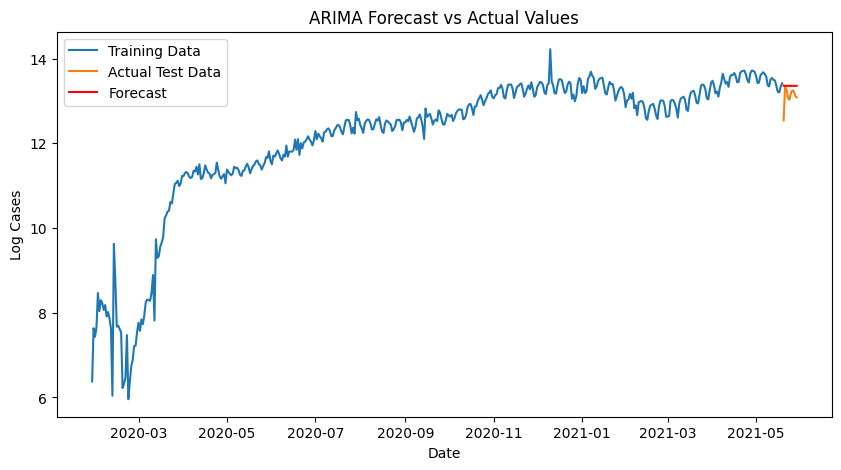

In [144]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, forecast, label="Forecast", color='red')

plt.title("ARIMA Forecast vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Log Cases")
plt.legend()
plt.show()

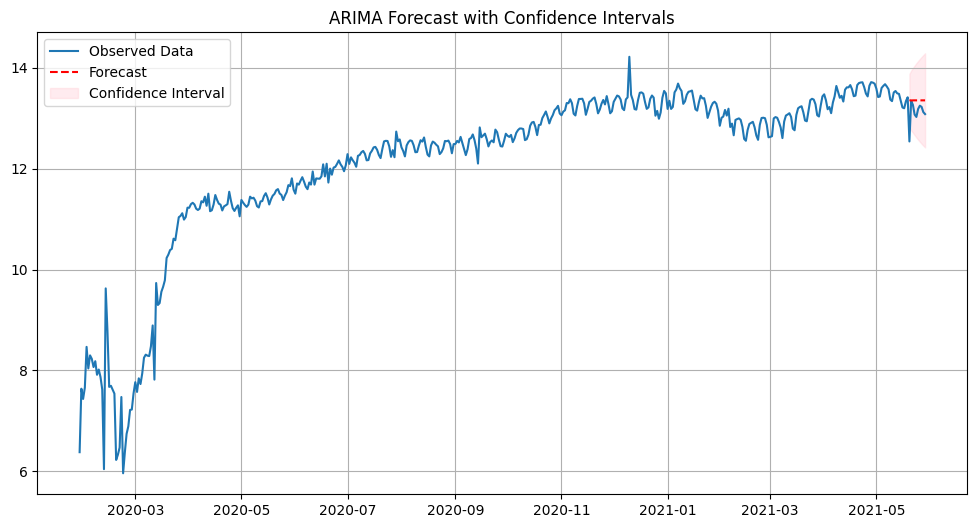

In [145]:
forecast_result = model_fit.get_forecast(steps=10)
conf_int = forecast_result.conf_int()

plt.figure(figsize=(12,6))

plt.plot(df['Log_Cases'], label="Observed Data")

plt.plot(forecast.index, forecast, 
         color='red', linestyle='--', label="Forecast")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color='pink',
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("ARIMA Forecast with Confidence Intervals")
plt.legend()
plt.grid(True)
plt.show()

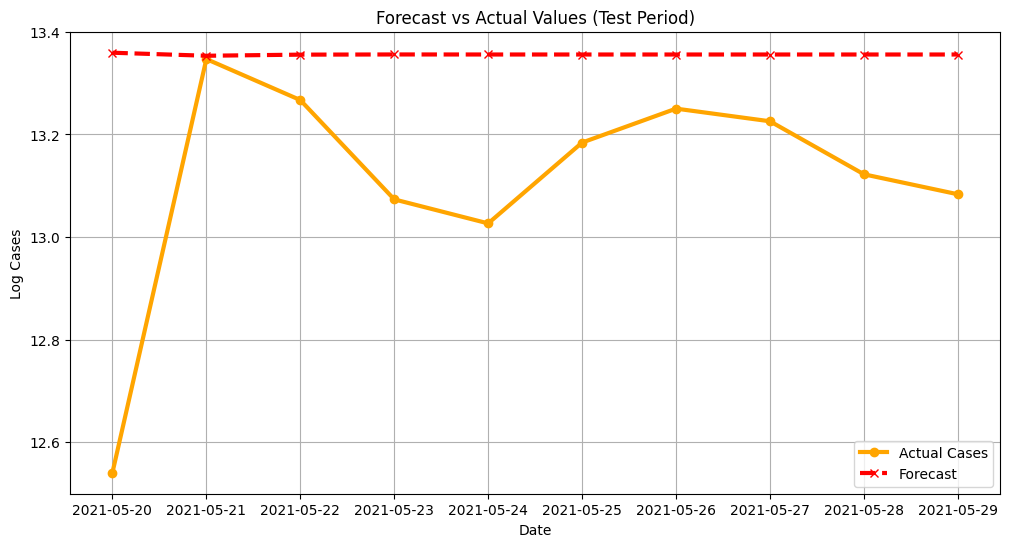

In [146]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Actual Cases", 
         color="orange", linewidth=3, marker='o')

plt.plot(test.index, forecast, label="Forecast", 
         color="red", linewidth=3, linestyle="--", marker='x')

plt.title("Forecast vs Actual Values (Test Period)")
plt.xlabel("Date")
plt.ylabel("Log Cases")

plt.legend()
plt.grid(True)

plt.show()